<a href="https://colab.research.google.com/github/jeandirel/NLP/blob/main/XAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install shap

# Task
Install the `shap` library, then import `shap`, `pandas`, `fetch_california_housing` from `sklearn.datasets`, `train_test_split` from `sklearn.model_selection`, and `RandomForestRegressor` from `sklearn.ensemble`. Load the California housing dataset, split it into training and testing sets, initialize a default `RandomForestRegressor` model, and fit the model on the training data.

## Import libraries

### Subtask:
Import `shap`, `pandas`, `fetch_california_housing` from `sklearn.datasets`, `train_test_split` from `sklearn.model_selection`, and `RandomForestRegressor` from `sklearn.ensemble`.


**Reasoning**:
Import the necessary libraries and functions as requested in the subtask.



In [2]:
import shap
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## Load data

### Subtask:
Load the California housing dataset.


**Reasoning**:
Use the `fetch_california_housing` function to load the dataset and store it in a variable.



In [3]:
california_housing = fetch_california_housing()

## Split data

### Subtask:
Split the data into training and testing sets.


**Reasoning**:
Split the data and target into training and testing sets using train_test_split.



In [4]:
X = california_housing.data
y = california_housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Prepare model

### Subtask:
Initialize a default instance of the `RandomForestRegressor`.


**Reasoning**:
Initialize a default instance of the RandomForestRegressor.



In [5]:
model = RandomForestRegressor()

## Fit model

### Subtask:
Fit the model on the training data.


**Reasoning**:
Fit the initialized RandomForestRegressor model to the training data.



In [6]:
model.fit(X_train, y_train)

RandomForestRegressor()

## Summary:

### Data Analysis Key Findings

*   The required libraries (`shap`, `pandas`, `sklearn`) were successfully imported.
*   The California housing dataset was loaded.
*   The dataset was split into training and testing sets with a test size of 20% and a random state of 42.
*   A default `RandomForestRegressor` model was initialized.
*   The `RandomForestRegressor` model was successfully fitted to the training data.

### Insights or Next Steps

*   The next logical step is to evaluate the performance of the fitted model on the testing data.
*   Explore using the `shap` library to interpret the model's predictions and understand feature importance.


## Calculate SHAP values

### Subtask:
Create a SHAP explainer object and calculate SHAP values for the test set.

**Reasoning**:
Use `shap.Explainer` to create an explainer object for the fitted `RandomForestRegressor` model. Then, calculate the SHAP values for the test dataset (`X_test`) using the explainer.

In [7]:
!pip -q install shap scikit-learn

In [8]:
# --- SHAP : explainer + calcul (RandomForest, California Housing) ---

import shap
from sklearn.utils import resample

# échantillons pour aller vite
X_bg  = resample(X_train, n_samples=min(100, len(X_train)), random_state=0, replace=False)
X_exp = resample(X_test,  n_samples=min(500, len(X_test)),  random_state=1, replace=False)

# explainer FastTreeSHAP + calcul
explainer   = shap.Explainer(model, X_bg, feature_perturbation="interventional")
shap_values = explainer(X_exp, check_additivity=False)


 99%|===================| 493/500 [00:55<00:00]       

In [9]:
shap_values

.values =
array([[-0.5296063 ,  0.07830217, -0.03824427, ..., -0.1439063 ,
         0.51704683,  0.05342025],
       [ 0.23312135, -0.13516934,  0.05579082, ..., -0.07192275,
        -0.14841581,  0.37740816],
       [ 0.31117401,  0.13041391, -0.02317705, ...,  1.19074595,
         0.45816011,  0.18307448],
       ...,
       [-0.48704701, -0.02706027, -0.05640983, ..., -0.07227161,
         0.0144678 , -0.49983569],
       [-0.16736197, -0.03440727, -0.04007698, ..., -0.19474433,
        -0.40321528,  0.19246476],
       [-0.10644495,  0.32494959, -0.0923052 , ...,  0.45179202,
         0.09788648,  0.9073636 ]])

.base_values =
array([1.98081702, 1.98081702, 1.98081702, 1.98081702, 1.98081702,
       1.98081702, 1.98081702, 1.98081702, 1.98081702, 1.98081702,
       1.98081702, 1.98081702, 1.98081702, 1.98081702, 1.98081702,
       1.98081702, 1.98081702, 1.98081702, 1.98081702, 1.98081702,
       1.98081702, 1.98081702, 1.98081702, 1.98081702, 1.98081702,
       1.98081702, 1.98081

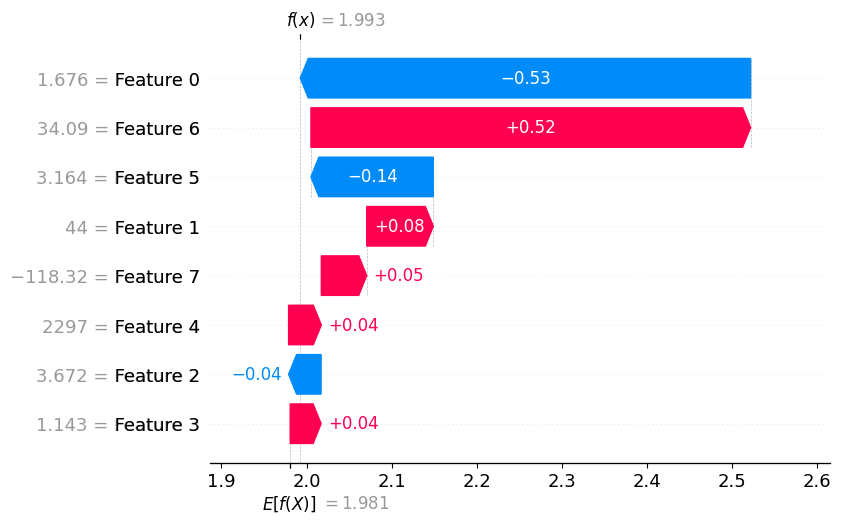

In [13]:
i = 0  # index de l'observation
shap.plots.waterfall(shap_values[i], max_display=20)


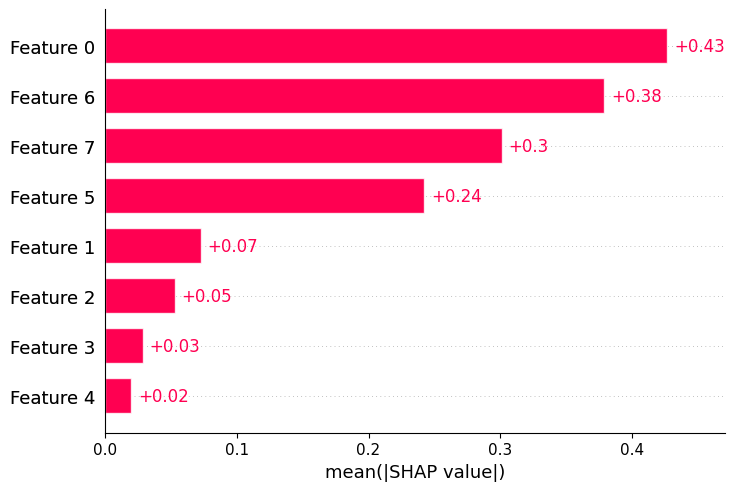

In [14]:
# --- Bar plot (importance moyenne absolue) ---
shap.plots.bar(shap_values, max_display=20)



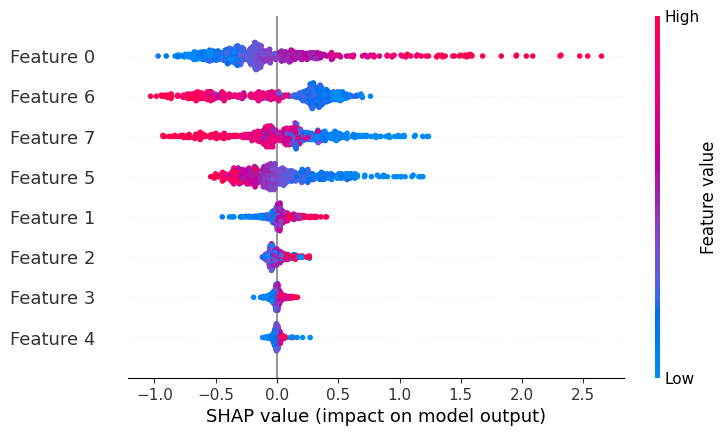

In [15]:
# --- Beeswarm plot (distribution des impacts) ---
shap.plots.beeswarm(shap_values, max_display=20)

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# load dataset
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

# create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.2, random_state=7)

# create DMatrix
import xgboost
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [17]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}

model = xgboost.train(
    params,
    d_train,
    num_boost_round=5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54659
[100]	test-logloss:0.36412
[200]	test-logloss:0.31812
[300]	test-logloss:0.30099
[400]	test-logloss:0.29237
[500]	test-logloss:0.28758
[600]	test-logloss:0.28477
[700]	test-logloss:0.28312
[800]	test-logloss:0.28211
[900]	test-logloss:0.28128
[1000]	test-logloss:0.28090
[1097]	test-logloss:0.28071


In [18]:
# Explain the model with TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Display the shap values
shap_values

array([[ 0.16937198, -0.39100432,  0.51752144, ..., -0.06714759,
        -0.25372657,  0.01469882],
       [ 0.37161916, -0.33237317,  0.6003703 , ..., -0.11175413,
        -1.2640297 ,  0.01965021],
       [ 0.07556684,  0.0088386 , -0.4644665 , ..., -0.05962565,
        -0.16355328,  0.00516177],
       ...,
       [ 0.55834985,  0.00606676, -0.4760173 , ..., -0.06190189,
        -0.17105791,  0.00928538],
       [-2.222302  , -0.05584413, -0.40143457, ..., -0.07904162,
        -1.0607618 , -0.02484922],
       [ 0.3993472 ,  0.20155272, -0.3216317 , ..., -0.03733327,
         0.01155926,  0.01602429]], dtype=float32)

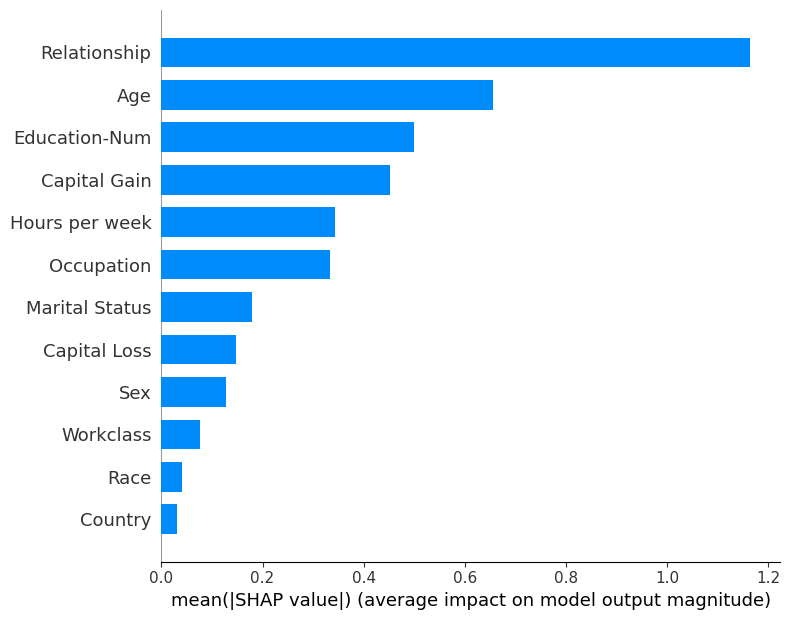

In [25]:
shap.summary_plot(shap_values, X_display, plot_type="bar")

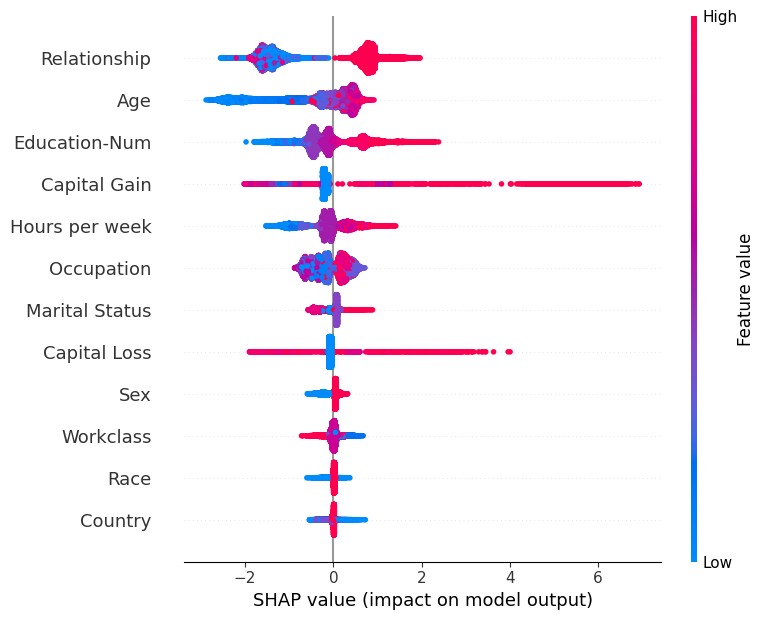

In [26]:
shap.summary_plot(shap_values, X)

## Insights from SHAP Summary Plot (Beeswarm Plot)

The SHAP summary plot (often displayed as a beeswarm plot) provides insights into the distribution of SHAP values for each feature across the dataset. Each dot on the plot represents a single instance from the dataset, and its position on the x-axis indicates the SHAP value for that instance and feature.

Here's how to interpret the plot for each variable:

*   **Vertical position:** Features are listed on the y-axis, typically ordered by their overall importance (mean absolute SHAP value), with the most important at the top.
*   **Horizontal position:** The position of a dot on the x-axis indicates the SHAP value for that specific feature and instance. A positive SHAP value means the feature increased the model's prediction, while a negative value means it decreased the prediction.
*   **Color:** The color of the dots usually represents the feature value for that instance (e.g., red for high values, blue for low values). This helps understand how feature values relate to their impact on the prediction.
*   **Density:** The density of the dots along the x-axis shows how many instances have a particular SHAP value for that feature.

By examining this plot for each variable, you can gain insights into:

*   **Feature importance:** Which features have the largest impact on predictions overall (wider spread of SHAP values).
*   **Direction of impact:** Whether a feature generally has a positive or negative impact on the prediction.
*   **Relationship between feature value and impact:** How the value of a feature (indicated by color) influences its impact on the prediction. For example, you might see that high values of a feature consistently lead to high positive SHAP values.
*   **Presence of interactions:** Sometimes the plot can reveal potential interactions between features, although dedicated interaction plots are better for this.

To get specific insights for each variable, you would look at its row in the plot and observe the distribution, color patterns, and range of SHAP values.

In [31]:
# Cellule séparée
shap.initjs()

i = 0
force_obj = shap.force_plot(
    explainer.expected_value,
    shap_values[i],          # au lieu de shap_values[0, :]
    X_display.iloc[i]        # au lieu de X_display[0, :]
)

force_obj   # affichage dans Jupyter


In [ ]:
import shap
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np
import xgboost
from sklearn.utils import resample


# California Housing Dataset
california_housing = fetch_california_housing()
X = california_housing.data
y = california_housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor()
model.fit(X_train, y_train)

# SHAP for RandomForest (California Housing)
X_bg = resample(X_train, n_samples=min(100, len(X_train)), random_state=0, replace=False)
X_exp = resample(X_test, n_samples=min(500, len(X_test)), random_state=1, replace=False)
explainer = shap.Explainer(model, X_bg, feature_perturbation="interventional")
shap_values_california = explainer(X_exp, check_additivity=False)

i = 0  # index de l'observation
shap.plots.waterfall(shap_values_california[i], max_display=20)
shap.plots.bar(shap_values_california, max_display=20)
shap.plots.beeswarm(shap_values_california, max_display=20)


# Adult Dataset
X_adult, y_adult = shap.datasets.adult()
X_display_adult, y_display_adult = shap.datasets.adult(display=True)

X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult, y_adult, test_size=0.2, random_state=7)
X_train_adult, X_validation_adult, y_train_adult, y_validation_adult = train_test_split(X_train_adult, y_train_adult, test_size=0.2, random_state=7)

d_train_adult = xgboost.DMatrix(X_train_adult, label=y_train_adult)
d_validation_adult = xgboost.DMatrix(X_validation_adult, label=y_validation_adult)
d_test_adult = xgboost.DMatrix(X_test_adult, label=y_test_adult)

params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.6,
    "base_score": np.mean(y_train_adult),
    "eval_metric": "logloss",
}

model_adult = xgboost.train(
    params,
    d_train_adult,
    num_boost_round=5000,
    evals=[(d_validation_adult, "validation")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

# SHAP for XGBoost (Adult)
explainer_adult = shap.TreeExplainer(model_adult)
shap_values_adult = explainer_adult.shap_values(X_adult)

shap.summary_plot(shap_values_adult, X_display_adult, plot_type="bar")
shap.summary_plot(shap_values_adult, X_adult)

shap.initjs()
shap.force_plot(explainer_adult.expected_value, shap_values_adult[0,:], X_display_adult[0,:])